In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("air_fryers_clean_brand_year.csv")

print(df.head())
print("\nShape:", df.shape)
print("\nBrands:", sorted(df["brand"].unique()))
print("Number of brands:", df["brand"].nunique())
print("Years:", sorted(df["year"].unique()))

     category  year       brand  purchase_count  product_count   avg_price  \
0  air_fryers  2019     chefman            1146             10   72.963695   
1  air_fryers  2019      cosori              11              2  159.990000   
2  air_fryers  2019   cuisinart            1616             22  229.465274   
3  air_fryers  2019        dash            3011             19   55.176333   
4  air_fryers  2019  gowise usa            4405             45   83.575551   

   avg_rating  compact_share  dual_basket_share  oven_style_share  \
0    4.434119       1.000000                0.0          0.780977   
1    4.581818       1.000000                0.0          0.090909   
2    4.481312       0.993812                0.0          0.889851   
3    4.390767       1.000000                0.0          0.973431   
4    4.552259       0.999773                0.0          0.129398   

   rotisserie_share  window_share  market_purchases  brand_share  \
0          0.243455      0.184119             15

In [5]:
coverage = (
    df.pivot_table(index="brand", columns="year", values="purchase_count", aggfunc="size", fill_value=0)
)
print(coverage)

year         2019  2020  2021  2022  2023
brand                                    
chefman         1     1     1     1     1
cosori          1     1     1     1     1
cuisinart       1     1     1     1     1
dash            1     1     1     1     1
gowise usa      1     1     1     1     1
instant_pot     1     1     1     1     1
ninja           1     1     1     1     1
nuwave          1     1     1     1     1
oster           1     1     1     1     1
ultrean         1     1     1     1     1


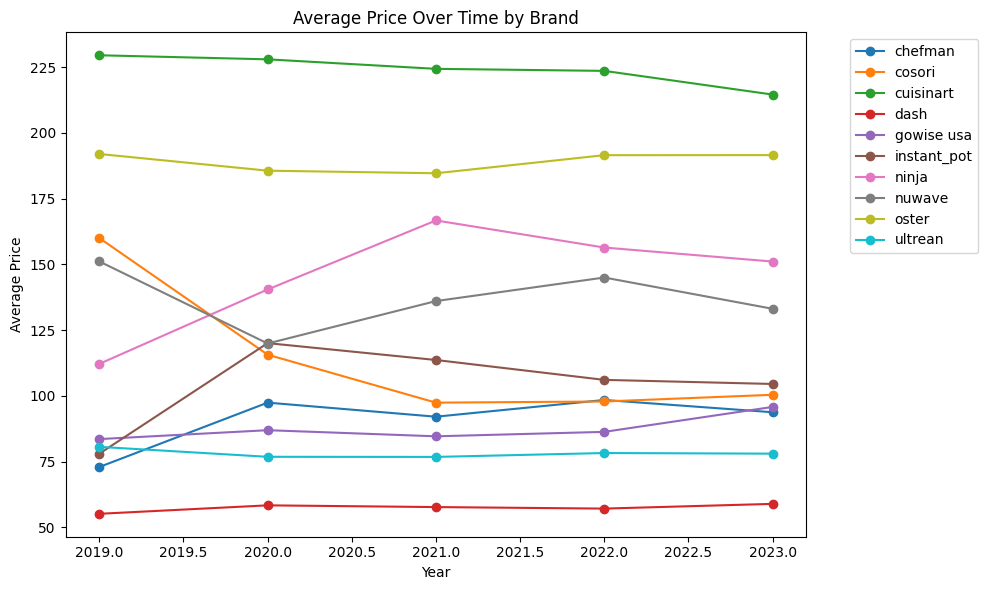

In [6]:
plt.figure(figsize=(10, 6))
for brand, g in df.groupby("brand"):
    g = g.sort_values("year")
    plt.plot(g["year"], g["avg_price"], marker="o", label=brand)

plt.xlabel("Year")
plt.ylabel("Average Price")
plt.title("Average Price Over Time by Brand")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

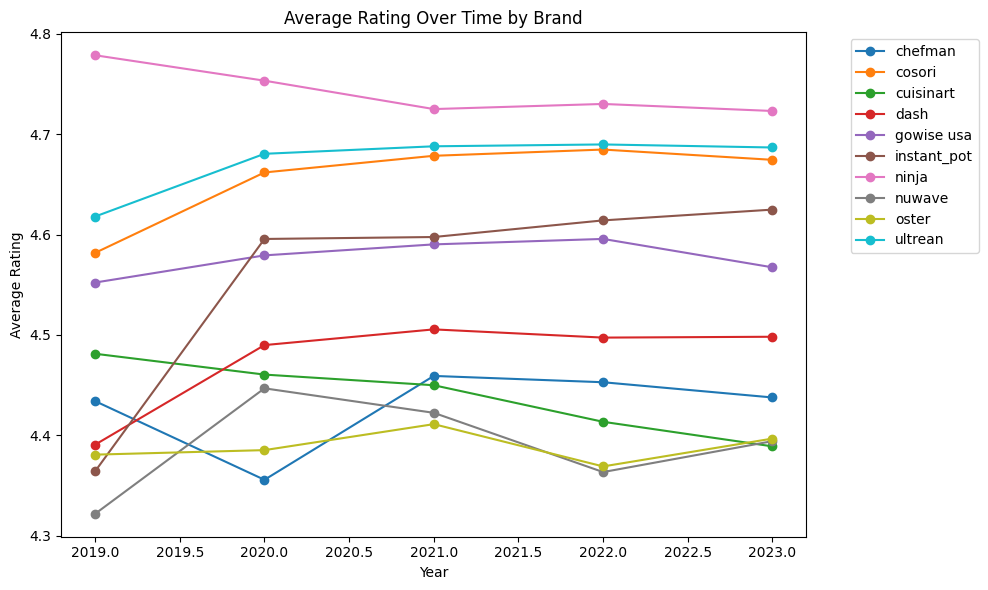

In [7]:
plt.figure(figsize=(10, 6))
for brand, g in df.groupby("brand"):
    g = g.sort_values("year")
    plt.plot(g["year"], g["avg_rating"], marker="o", label=brand)

plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.title("Average Rating Over Time by Brand")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

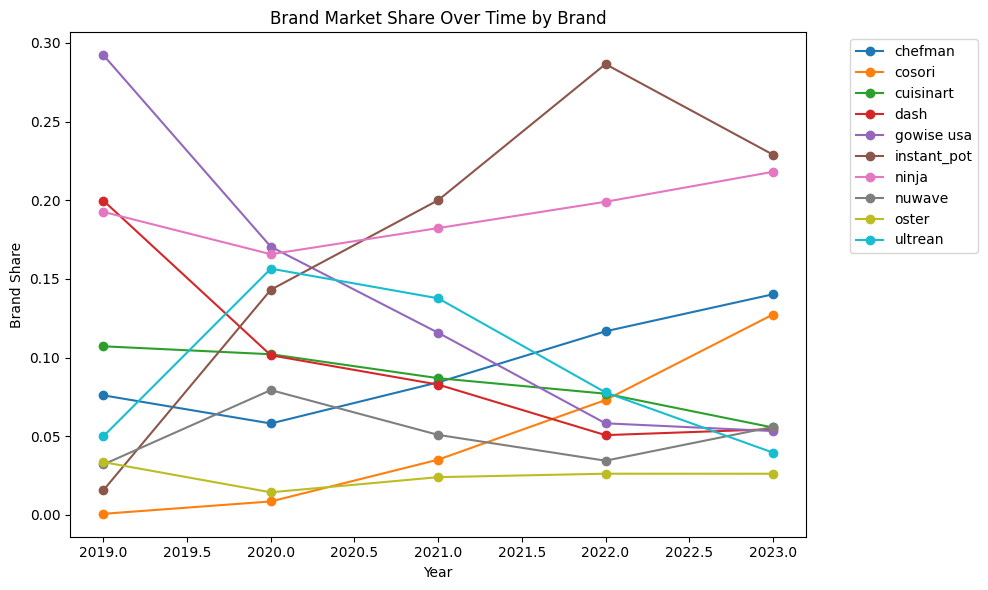

In [8]:
plt.figure(figsize=(10, 6))
for brand, g in df.groupby("brand"):
    g = g.sort_values("year")
    plt.plot(g["year"], g["brand_share"], marker="o", label=brand)

plt.xlabel("Year")
plt.ylabel("Brand Share")
plt.title("Brand Market Share Over Time by Brand")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [9]:
feature_cols = [
    "compact_share",
    "dual_basket_share",
    "oven_style_share",
    "rotisserie_share",
    "window_share"
]

feature_summary = df[feature_cols].mean().sort_values(ascending=False)
print(feature_summary)

compact_share        0.980081
oven_style_share     0.562647
rotisserie_share     0.070762
window_share         0.036741
dual_basket_share    0.002260
dtype: float64


In [10]:
brand_feature_summary = (
    df.groupby("brand")[feature_cols]
      .mean()
      .sort_values(by=feature_cols, ascending=False)
)
print(brand_feature_summary.round(3))

             compact_share  dual_basket_share  oven_style_share  \
brand                                                             
oster                1.000              0.000             0.865   
ultrean              1.000              0.000             0.830   
gowise usa           1.000              0.000             0.184   
dash                 0.999              0.000             0.890   
cosori               0.997              0.000             0.030   
cuisinart            0.996              0.000             0.913   
nuwave               0.995              0.007             0.543   
ninja                0.992              0.002             0.100   
chefman              0.962              0.013             0.597   
instant_pot          0.860              0.000             0.675   

             rotisserie_share  window_share  
brand                                        
oster                   0.000         0.000  
ultrean                 0.000         0.000  
gowise usa 

In [11]:
feature_means = df[feature_cols].mean().sort_values(ascending=False)

print("Most common features:")
print(feature_means.head())

print("\nRarest features:")
print(feature_means.tail())

Most common features:
compact_share        0.980081
oven_style_share     0.562647
rotisserie_share     0.070762
window_share         0.036741
dual_basket_share    0.002260
dtype: float64

Rarest features:
compact_share        0.980081
oven_style_share     0.562647
rotisserie_share     0.070762
window_share         0.036741
dual_basket_share    0.002260
dtype: float64


In [12]:
specialization = df.groupby("brand")[feature_cols].mean()

for col in feature_cols:
    top_brand = specialization[col].idxmax()
    top_value = specialization[col].max()
    print(f"{col}: {top_brand} ({top_value:.3f})")

compact_share: oster (1.000)
dual_basket_share: chefman (0.013)
oven_style_share: cuisinart (0.913)
rotisserie_share: chefman (0.370)
window_share: chefman (0.363)


In [13]:
brand_summary = (
    df.groupby("brand")
      .agg(
          avg_price=("avg_price", "mean"),
          avg_rating=("avg_rating", "mean"),
          avg_share=("brand_share", "mean"),
          total_purchases=("purchase_count", "sum"),
          avg_products=("product_count", "mean")
      )
      .sort_values("avg_share", ascending=False)
)

print(brand_summary.round(3))

             avg_price  avg_rating  avg_share  total_purchases  avg_products
brand                                                                       
ninja          145.343       4.742      0.192            20074          42.2
instant_pot    104.461       4.559      0.175            19426          33.8
gowise usa      87.455       4.577      0.138            14962          33.6
dash            57.479       4.476      0.098            10295          24.2
chefman         90.938       4.428      0.095             9437          13.6
ultrean         78.115       4.673      0.092            11914           5.6
cuisinart      223.947       4.439      0.086             9676          32.8
nuwave         137.024       4.390      0.051             5741          19.2
cosori         114.268       4.656      0.049             4147           7.6
oster          189.031       4.389      0.025             2521           8.4


In [14]:
year_summary = (
    df.groupby("year")
      .agg(
          total_purchases=("purchase_count", "sum"),
          avg_price=("avg_price", "mean"),
          avg_rating=("avg_rating", "mean")
      )
)

print(year_summary.round(3))

      total_purchases  avg_price  avg_rating
year                                        
2019            15076    121.502       4.490
2020            30291    122.916       4.541
2021            30850    123.393       4.553
2022            23576    124.051       4.541
2023             8400    122.169       4.539


1. Verify the data contain 10 brands and the years 2019–2023

The dataset contains 10 air-fryer brands observed over the years 2019 through 2023. Each row represents one brand in one year, so the panel is organized at the brand-year level.

2. Describe prices, ratings, and market shares over time

Average prices differ a lot across brands. Cuisinart and Oster are consistently the most expensive brands, while Dash, Ultrean, and Chefman are among the lower-priced brands. Ratings are more compressed than prices, with most brands falling in a fairly narrow range. In market share, leadership changes over time: GoWise USA begins with a large share, while Instant Pot, Ninja, and later Chefman/Cosori become more important over time.

3. Which features are common? Which are rare?

The most common feature is compact design, which is almost universal in the sample. Oven-style is also fairly common. The rarest features are dual basket, window, and rotisserie, which appear much less often overall.

4. Are there brands that specialize in different product types?

Yes. Some brands appear more specialized than others. For example, Chefman stands out in rotisserie and window features, while Cuisinart has a high oven-style share. This suggests that brands compete not just on price, but also on product design and feature emphasis.

5. Describe the market

The air-fryer market shows clear differences across brands in both price and market position. Cuisinart is the most expensive brand throughout the period, with Oster also consistently priced at the high end, while Dash, Ultrean, Chefman, and GoWise USA are generally among the lower-priced brands. In terms of market share, the leaders change over time rather than staying fixed. GoWise USA starts with a very large share in 2019, but its share declines sharply over time. Instant Pot grows quickly and becomes one of the biggest brands by 2022, while Ninja also maintains a large and rising share. Overall, the market does not look completely stable over time because both shares and some prices shift noticeably, suggesting changing consumer preferences and stronger competition among brands.